
# Introduction to Python Functions
In data analysis, we often need to perform the same sequence of calculations multiple times. Instead of copying and pasting the same code we can define a function. You can think of a function as a mini-program taking an input, doing some work, and returning an output.

**Basic Syntax**
- `def`: The keyword that tells Python you are defining a function.

- Function Name: A descriptive name for your operation.

- Arguments: The inputs the function needs to run, enclosed in parentheses.

- Docstring: A multi-line string `"""like this"""` that explains what the function does.

- return: The keyword that passes the final calculated value back to the user.

In [11]:
## ---- EXAMPLE ---- ##
import numpy as np

def say_my_name(name):
    """
    Takes a name as input and prints a greeting
    """

    greeting = f"Hola, {name}! "
    
    return print(greeting)

In [12]:
# test our function
say_my_name("Shakira")

Hola, Shakira! 


### Computing Significant Wave Height, $H_s$

The significant wave height, $H_s$, is a commonly used parameter in oceanography to describe the average height of the highest one-third of waves in a wave spectrum. It is calculated using the formula:
$$m_0 = \int_0^\infty S(f) df$$
$$H_s = 4 \sqrt{m_0}$$
where:
- $S(f)$ is the spectral energy density 
- $df$ is the frequency resolution (sampling frequency / number of data points)
- $m_0$ is the zeroth moment of the wave spectrum, representing the total energy of the waves.

** Steps for computing $H_s$:
1. extract the pressure data from an xarray
2. **define dimensions** N (number of data points) and df (sampling frequency)
3. **Compute the FFT**
4. **Isolate positive frequencies**: raw FFT output includes both positive and negative frequencies. We only need the positive frequencies for our analysis.
5. **Calculate spectral density (S)** $$S(f) = \frac{2*|X(f)|^2}{N * f_s}$$ where $X(f)$ is the absolute magnitudeFFT output, $N$ is the number of data points, and $f_s$ is the sampling frequency.
6. **Isolate desired frequency band** create a boolean mask using fmin and fmax
6. **Integrate for variance $m_0$**: $$m_0 = \sum S(f) * df$$ Sum the energy density across all frequencies and multiply by df
7. **Calculate significant wave height**: $$H_s = 4 \sqrt{m_0}$$


In [ ]:
from scipy.io import loadmat
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# load and unpack the data
mat = loadmat('CMI_data.mat')
cmi_data = mat['CMI'][0, 0]

# convert the5400x200 time matrix from datenum to datetime objects
t_flat = cmi_data['t'].flatten()
times_2d = pd.to_datetime(t_flat - 719529, unit='D').values.reshape(5400, 200)

# build the Dataset
ds = xr.Dataset(
    data_vars={
        var: (["row", "col"], cmi_data[var]) 
        for var in ['p2', 'p3', 'p4', 'p6', 'p7', 'e7']
    },
    coords={
        "time": (["row", "col"], times_2d),
        "row": np.arange(5400),
        "col": np.arange(200),
    }
)

ds

In [45]:
import numpy as np

def compute_hs(dataset, variable_name, fs, fmin, fmax):
    """
    Computes significant wave height (Hs) across all bursts simultaneously.
    Returns a 1D array of Hs values (length 200).
    """
    # 1. Extract the 2D time series (rows=time, cols=bursts)
    x = dataset[variable_name].values
    
    # 2. Define dimensions (N = 5400 samples)
    N = x.shape[0]
    df = fs / N

    # 3. Compute the FFT along the time axis (axis=0)
    fft = np.fft.fft(x, axis=0)

    # 4. Isolate the positive frequencies
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_idx = freqs > 0
    freqs_pos = freqs[pos_idx]
    
    # Subset the 2D FFT array for positive frequencies
    fft_pos = fft[pos_idx, :]

    # 5. Calculate energy spectrum 
    S = (2 / (N * fs)) * np.abs(fft_pos)**2

    # 6. Create a mask for the specified frequency band
    mask = (freqs_pos >= fmin) & (freqs_pos <= fmax)
    
    # Apply the mask to the rows (frequencies)
    S_band = S[mask, :]

    # 7. Compute variance (m0) by summing along the frequency axis (axis=0)
    m0 = np.sum(S_band * df, axis=0)

    # 8. Compute Hs for all 200 bursts
    Hs = 4 * np.sqrt(m0)

    return Hs

In [39]:
Hig = compute_hs(ds, 'p2', fs=1, fmin= 1/25, fmax=1/900)

In [43]:
fs = 1.0          # 1 Hz sampling rate from 1-second measurements [cite: 26]
ss_fmin = 1/25    # Lower limit for SS band 
ss_fmax = 0.5     # Upper limit (Nyquist frequency is fs / 2)

hs_ss_p2 = compute_hs(ds, 'p2', fs, ss_fmin, ss_fmax)
hs_ss_p3 = compute_hs(ds, 'p3', fs, ss_fmin, ss_fmax)
hs_ss_p4 = compute_hs(ds, 'p4', fs, ss_fmin, ss_fmax)
hs_ss_p6 = compute_hs(ds, 'p6', fs, ss_fmin, ss_fmax)
hs_ss_e7 = compute_hs(ds, 'e7', fs, ss_fmin, ss_fmax)


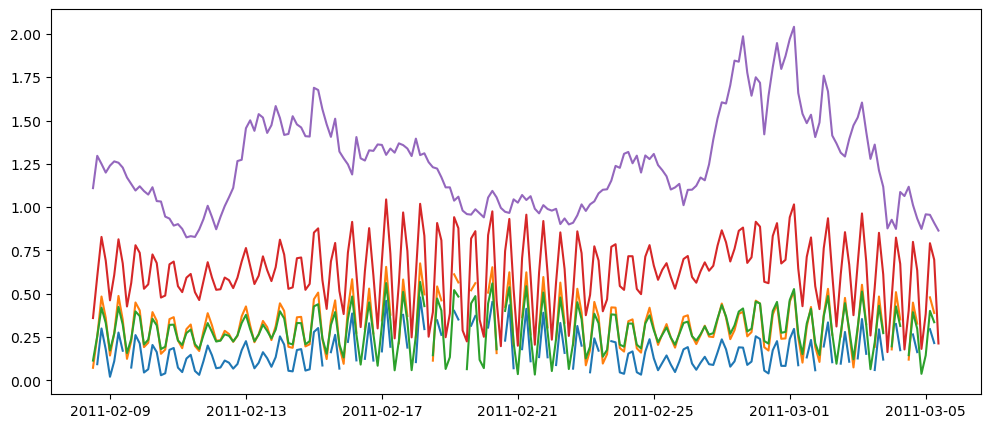

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(ds.time[0,:], hs_ss_p2)
plt.plot(ds.time[0,:], hs_ss_p3)
plt.plot(ds.time[0,:], hs_ss_p4)
plt.plot(ds.time[0,:], hs_ss_p6)
plt.plot(ds.time[0,:], hs_ss_e7)
